### 1. Library imports and dataframe creation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [3]:
splits = {'train': 'train.json', 'validation': 'validation.json'}
df = pd.read_json("hf://datasets/AdamLucek/apple-environmental-report-QA-retrieval/" + splits["train"])

C:\Users\rueda\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Data visualization

In [4]:
df.head()

,question,chunk
0,What types of workshops does a business offer ...,"standard for factories, helping facilitate eff..."
1,What's the breakdown of renewable energy usage...,Default grid mix % x Apple actual renewable en...
2,Are there any recent renewable energy projects...,"2019, will meet all the data center’s near-ter..."
3,Is my device from a few years ago still eligib...,the latest features available to their device ...
4,How do they determine the value of my old devi...,we sent nearly 12. 8 million devices and acces...


In [5]:
df.tail(5)

,question,chunk
3435,Is there a report on energy use from renewable...,"grid. As our loads grow over time, we’ll conti..."
3436,What challenges exist in creating a circular s...,"elements, steel, tantalum, tin, titanium, tung..."
3437,How much has the renewable energy capacity inc...,"International MWh 657,000 585,000 477,000 389,..."
3438,How does the company ensure the accuracy of it...,Avoided GHG Emissions 18.51 Million metric t...
3439,What kind of renewable energy projects is the ...,We invest capital in new solar PV or wind proj...


### 3. Analyze chunk length distribution 

--- Text Statistics ---
        char_count   word_count
count  3440.000000  3440.000000
mean   3334.449709   479.872965
std     341.333642    47.947380
min    1957.000000   260.000000
25%    3227.000000   469.000000
50%    3426.000000   492.000000
75%    3548.000000   512.000000
max    4122.000000   547.000000


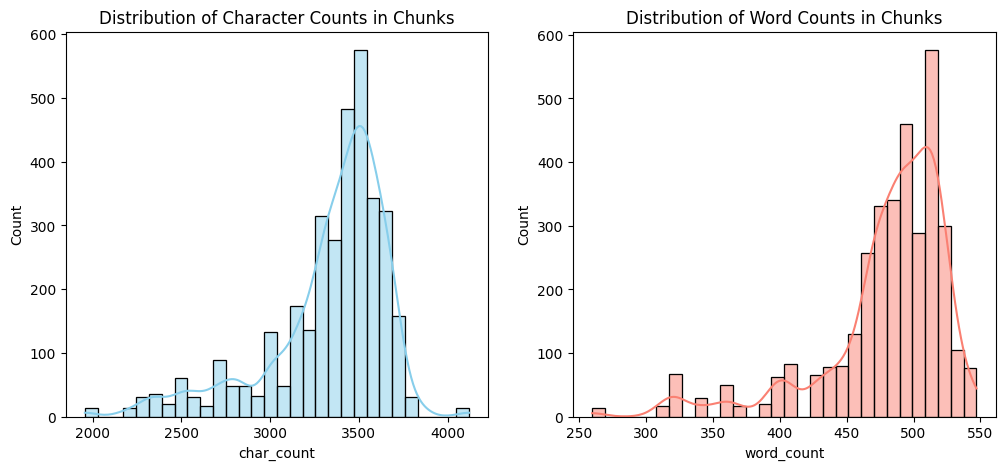

In [4]:
df['char_count'] = df['chunk'].apply(len)
df['word_count'] = df['chunk'].apply(lambda x: len(x.split()))

print("--- Text Statistics ---")
print(df[['char_count', 'word_count']].describe())

# Plotting the distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['char_count'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Character Counts in Chunks')

plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Word Counts in Chunks')
plt.show()

### 4. Domain Vocabulary Density - word frequency

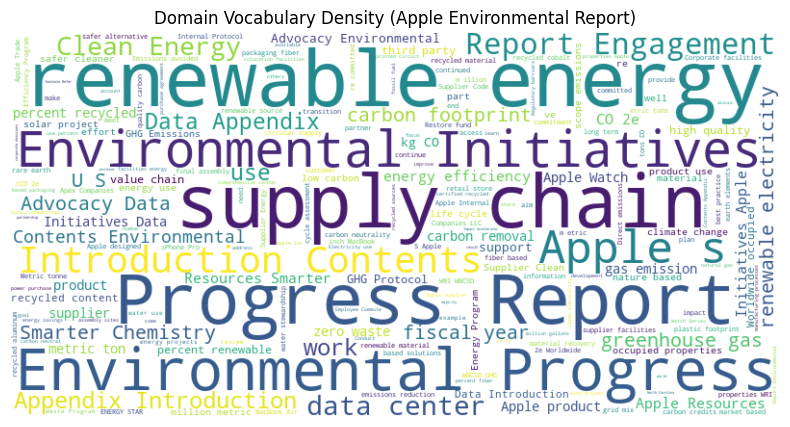

In [5]:
text_combined = " ".join(df['chunk'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Domain Vocabulary Density (Apple Environmental Report)')
plt.show()

### 5. Analyze Question Types:  look for common starting words to identify question patterns

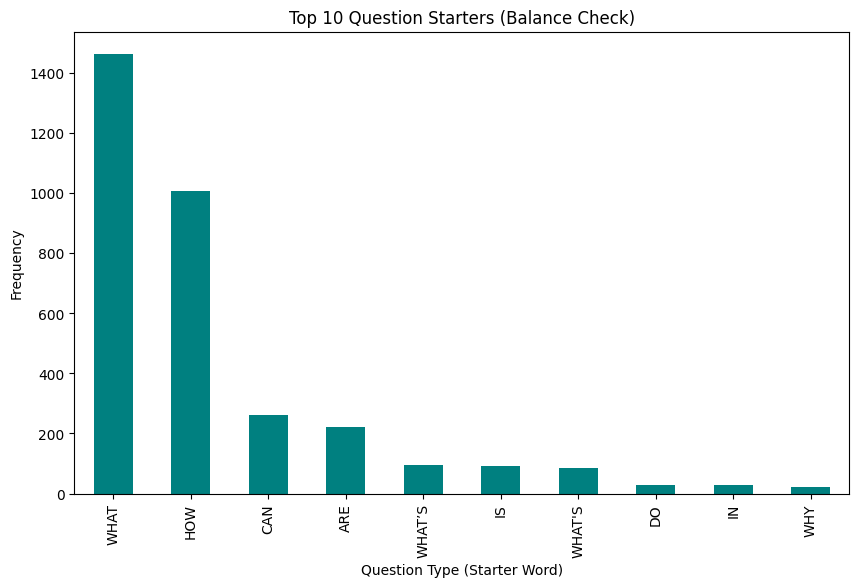

In [7]:
df['question_start'] = df['question'].apply(lambda x: x.split()[0].upper() if len(x.split()) > 0 else "N/A")
question_counts = df['question_start'].value_counts().head(10)

plt.figure(figsize=(10, 6))
question_counts.plot(kind='bar', color='teal')
plt.title('Top 10 Question Starters (Balance Check)')
plt.ylabel('Frequency')
plt.xlabel('Question Type (Starter Word)')
plt.show()

### 6. Manual Inspection Sample: Identify potentially noisy or ambiguous entries for the Router's baseline

In [8]:
print("--- Manual Inspection Sample (First 5 entries) ---")
for i, row in df.head(5).iterrows():
    print(f"Q: {row['question']}")
    print(f"A (Chunk): {row['chunk'][:150]}...") # Printing first 150 chars
    print("-" * 30)

--- Manual Inspection Sample (First 5 entries) ---
Q: What types of workshops does a business offer for its suppliers to promote sustainability?
A (Chunk): standard for factories, helping facilitate efforts to 
decarbonize operations across our supply chain, 
driving water reuse across sites, establishing...
------------------------------
Q: What's the breakdown of renewable energy usage for the data centers?
A (Chunk): Default grid mix % x Apple actual renewable energy allocation %
Gas 43 Apple’s solar projects 88
Nuclear 32 Apple’s wind projects 12
Coal 11 Source: 2...
------------------------------
Q: Are there any recent renewable energy projects powering data centers in Denmark?
A (Chunk): 2019, will meet all the data center’s near-term energy 
needs, and at 42 m egawatts, is one of Denmark’s 
largest solar power plants. Our second renew...
------------------------------
Q: Is my device from a few years ago still eligible for software updates?
A (Chunk): the latest features availa

### 7. Semantic similarity between questions

C:\Users\rueda\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rueda\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3812.33it/s]
BertModel LOAD RE

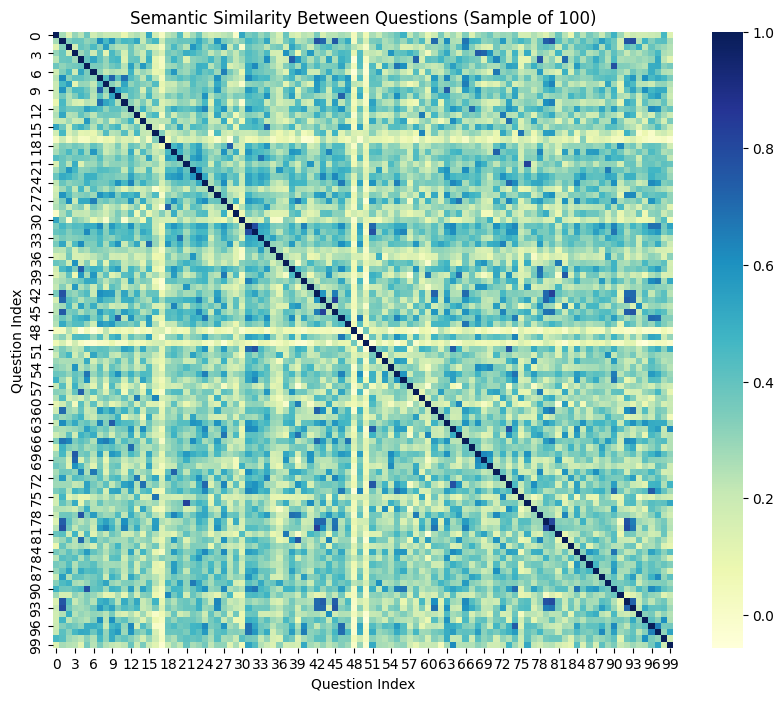

Mean Similarity: 0.3256


In [9]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Load the model you chose in the proposal
model = SentenceTransformer('all-MiniLM-L6-v2')

# Sample 100 questions to avoid memory issues in the heatmap
sample_questions = df['question'].sample(100, random_state=42).tolist()
q_embeddings = model.encode(sample_questions)

# Calculate Cosine Similarity
sim_matrix = cosine_similarity(q_embeddings)

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, cmap='YlGnBu')
plt.title('Semantic Similarity Between Questions (Sample of 100)')
plt.xlabel('Question Index')
plt.ylabel('Question Index')
plt.show()

print(f"Mean Similarity: {sim_matrix.mean():.4f}")

### 8. Lexical overlap: Question vs Chunk

RAG often fails when question and answer do not share words in common.

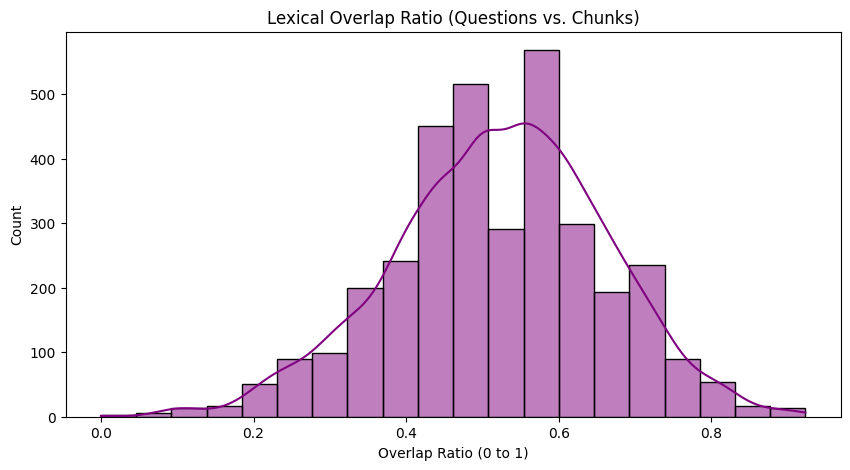

Average Lexical Overlap: 0.52


In [10]:
def calculate_overlap(row):
    q_words = set(row['question'].lower().split())
    c_words = set(row['chunk'].lower().split())
    if not q_words: return 0
    return len(q_words.intersection(c_words)) / len(q_words)

df['lexical_overlap'] = df.apply(calculate_overlap, axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(df['lexical_overlap'], bins=20, color='purple', kde=True)
plt.title('Lexical Overlap Ratio (Questions vs. Chunks)')
plt.xlabel('Overlap Ratio (0 to 1)')
plt.show()

print(f"Average Lexical Overlap: {df['lexical_overlap'].mean():.2f}")

### 9. Answer Length vs Chunck Length

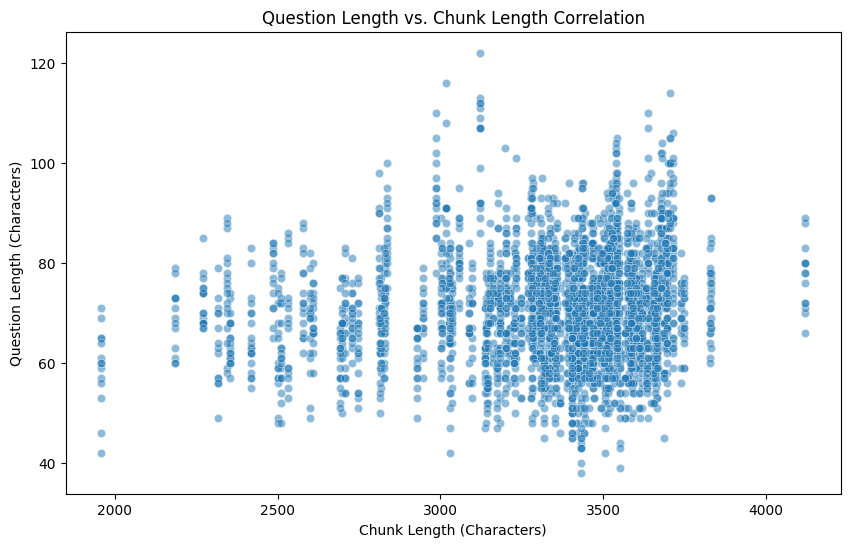

In [11]:
# Assuming your dataset has an 'answer' or 'ground_truth' column 
# If it only has question/chunk, we compare Question vs Chunk density
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='char_count', y=df['question'].apply(len), alpha=0.5)
plt.title('Question Length vs. Chunk Length Correlation')
plt.xlabel('Chunk Length (Characters)')
plt.ylabel('Question Length (Characters)')
plt.show()